<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
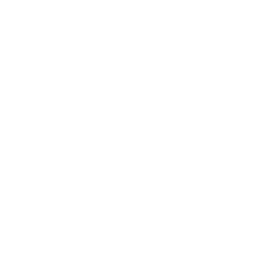
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Nuclear Power Plant Safety Incident Rate Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Nuclear Energy / Regulatory Safety Compliance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Estimate reactor safety incident rates across five nuclear generating units using PROC RAREEVENTS with the exact Poisson method, which is the regulatory standard when event counts are very small. Compute 95% confidence intervals for incidents per reactor-operating-hour by facility unit. Use BY-group processing to analyze each unit class (pressurized water reactor versus boiling water reactor) separately. Export confidence interval bounds for inclusion in the NRC 10 CFR Part 50 annual performance indicator submittal.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.REACTOR_INCIDENTS | Safety-significant incidents by reactor unit and quarter with operating hours | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic nuclear plant safety incident data
   100 quarterly observations across 5 reactor units over
   5 years (2001-2005). Events are rare: ~0.7 per
   unit-quarter, so most quarters see zero or one incident.
   -------------------------------------------------------- */
data work.reactor_incidents;
    call streaminit(42);
    length unit_id $8 reactor_type $3 plant_name $20;
    array units[5] $8 _temporary_ ('UNIT-1A' 'UNIT-1B' 'UNIT-2A' 'UNIT-2B' 'UNIT-3A');
    array rtype[5] $3 _temporary_ ('PWR' 'PWR' 'BWR' 'BWR' 'PWR');
    array plant[5] $20 _temporary_ ('NORTHERN STATION' 'NORTHERN STATION'
        'COASTAL NUCLEAR' 'COASTAL NUCLEAR' 'INLAND PLANT');
    array base_rate[5] _temporary_ (0.6 0.9 1.1 0.7 0.4);
    do year = 2001 to 2005;
        do quarter = 1 to 4;
            do unit_idx = 1 to 5;
                unit_id     = units[unit_idx];
                reactor_type = rtype[unit_idx];
                plant_name  = plant[unit_idx];
                /* Operating hours per quarter: 2190 hrs at 100%, minus outages */
                outage_hrs  = max(0, rand('normal', 120, 80));
                operating_hours = round(2190 - outage_hrs, 1);
                if operating_hours < 400 then operating_hours = 400;
                /* Incidents: Poisson with unit-specific base rate */
                lambda = base_rate[unit_idx] * operating_hours / 2000;
                safety_incidents = rand('poisson', lambda);
                /* Corrective action program entries (higher volume) */
                cap_entries = rand('poisson', 18 + unit_idx * 2);
                /* Unplanned scrams */
                scrams = rand('poisson', 0.3);
                obs_year    = year;
                obs_quarter = quarter;
                /* Continuous quarterly time index for plotting */
                time_index  = year + (quarter - 1)/4;
                output;
            end;
        end;
    end;
    drop unit_idx base_rate lambda outage_hrs;
    format operating_hours 8.1;
run;

/* Sort by reactor type for BY-group processing */
proc sort data=work.reactor_incidents;
    by reactor_type unit_id time_index;
run;

NOTE: DATA work.reactor_incidents


NOTE: Wrote work.reactor_incidents (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.reactor_incidents

NOTE: Read 100 rows from work.reactor_incidents.
NOTE: Wrote work.reactor_incidents (100 rows, 12 columns).
NOTE: PROC SORT statement used.


---

                                        Safety Incident Summary by Reactor Unit                                         

                                                  The MEANS Procedure

                                          Analysis Variable : safety_incidents

        reactor_type  unit_id           N Obs            Sum           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------------
        BWR           UNIT-2A              20     20.0000000      1.0000000      0.9176629      0.0000000      3.0000000
        BWR           UNIT-2B              20     17.0000000      0.8500000      0.8750940      0.0000000      3.0000000
        PWR           UNIT-1A              20      9.0000000      0.4500000      0.7591547      0.0000000      2.0000000
        PWR           UNIT-1B              20     21.0000000      1.0500000      1.1909748      0.0000000      5.0000000
 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_safety_incidents.spec.json
NOTE: PROC FREQ statement used.


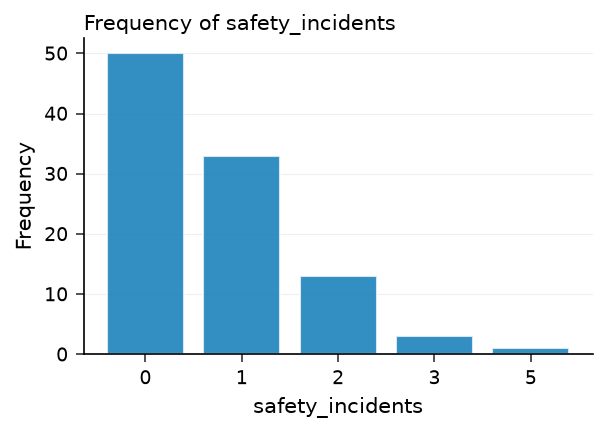

In [2]:
/* --------------------------------------------------------
   Baseline incident counts and operating hours by unit
   -------------------------------------------------------- */
proc means data=work.reactor_incidents n sum mean std min max;
    class reactor_type unit_id;
    var safety_incidents operating_hours scrams;
    title 'Safety Incident Summary by Reactor Unit';
run;

/* Raw incident frequency table */
proc freq data=work.reactor_incidents;
    tables safety_incidents / nocum;
    title 'Distribution of Quarterly Incident Counts';
run;

---

                                       Distribution of Quarterly Incident Counts                                        

PROC SGPANEL Output
Data: work.reactor_incidents

Variables: unit_id, reactor_type, plant_name, year, quarter, operating_hours, safety_incidents, cap_entries, scrams, obs_year, obs_quarter, time_index

   unit_id  reactor_type  plant_name        year     quarter  operating_hours  safety_incidents  cap_entries      scrams    obs_year  obs_quarter  time_index
----------  ------------  ----------  ----------  ----------  ---------------  ----------------  -----------  ----------  ----------  -----------  ----------
   UNIT-2A           BWR  COASTAL NUCLEAR        2001           1             2005                 1           21           0        2001            1        2001
   UNIT-2A           BWR  COASTAL NUCLEAR        2001           2             2115                 0           18           0        2001            2     2001.25
   UNIT-2A           BWR  COASTAL 

NOTE: PROC SGPANEL data=work.reactor_incidents

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


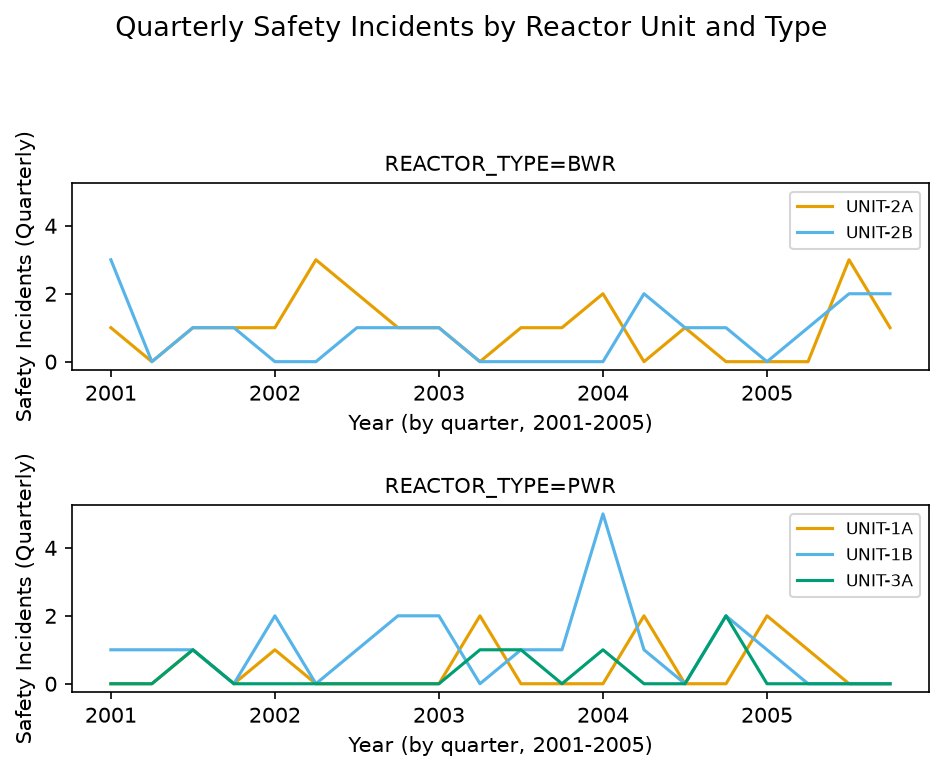

In [3]:
/* --------------------------------------------------------
   Time series of safety incidents by reactor type
   -------------------------------------------------------- */
proc sgpanel data=work.reactor_incidents;
    panelby reactor_type / columns=1;
    series x=time_index y=safety_incidents / group=unit_id
        lineattrs=(thickness=1.5);
    colaxis label='Year (by quarter, 2001-2005)';
    rowaxis label='Safety Incidents (Quarterly)';
    keylegend / location=inside position=topright;
    title 'Quarterly Safety Incidents by Reactor Unit and Type';
run;

---

In [4]:
/* --------------------------------------------------------
   Exact Poisson confidence intervals for incident rate
   by reactor unit — the NRC-preferred method for rare
   events with small counts
   -------------------------------------------------------- */
proc rareevents data=work.reactor_incidents;
    by reactor_type unit_id;
    var safety_incidents;
    exposure operating_hours;
    method exact;
    title 'Safety Incident Rate per Operating Hour — Exact Poisson CIs';
run;

                                       Distribution of Quarterly Incident Counts                                        


                    The RAREEVENTS Procedure

  BY Group:         reactor_type=BWR, unit_id=UNIT-2A
  Method:           Exact
  Alpha:            0.0500
  Observations:     20
  Total events:     20.0
  Total exposure:   41727.0
  Event rate:       0.000479
  95% CI:        (0.000293, 0.000740)



                    The RAREEVENTS Procedure

  BY Group:         reactor_type=BWR, unit_id=UNIT-2B
  Method:           Exact
  Alpha:            0.0500
  Observations:     20
  Total events:     17.0
  Total exposure:   41597.0
  Event rate:       0.000409
  95% CI:        (0.000238, 0.000654)



                    The RAREEVENTS Procedure

  BY Group:         reactor_type=PWR, unit_id=UNIT-1A
  Method:           Exact
  Alpha:            0.0500
  Observations:     20
  Total events:     9.0
  Total exposure:   41427.0
  Event rate:       0.000217
  95% CI:        (0.00

NOTE: PROC RAREEVENTS
NOTE: PROC RAREEVENTS statement used.


In [5]:
/* --------------------------------------------------------
   Compare Exact vs Byar approximation for all units
   aggregated. Byar is a fast alternative for regulatory
   reporting software that cannot use exact methods.
   -------------------------------------------------------- */
proc rareevents data=work.reactor_incidents;
    by reactor_type;
    var safety_incidents;
    exposure operating_hours;
    method byar;
    title 'Safety Incident Rate — Byar Approximation by Reactor Type';
run;

                                       Distribution of Quarterly Incident Counts                                        


                    The RAREEVENTS Procedure

  BY Group:         reactor_type=BWR
  Method:           Byar
  Alpha:            0.0500
  Observations:     40
  Total events:     37.0
  Total exposure:   83324.0
  Event rate:       0.000444
  95% CI:        (0.000313, 0.000612)



                    The RAREEVENTS Procedure

  BY Group:         reactor_type=PWR
  Method:           Byar
  Alpha:            0.0500
  Observations:     60
  Total events:     36.0
  Total exposure:   124411.0
  Event rate:       0.000289
  95% CI:        (0.000203, 0.000401)




NOTE: PROC RAREEVENTS
NOTE: PROC RAREEVENTS statement used.


In [6]:
/* --------------------------------------------------------
   Capture rate estimates to output dataset for NRC
   performance indicator submittal package
   -------------------------------------------------------- */
proc rareevents data=work.reactor_incidents
        out=work.nrc_pi_results noprint;
    by reactor_type unit_id;
    var safety_incidents;
    exposure operating_hours;
    method exact;
run;

proc print data=work.nrc_pi_results;
    title 'NRC Performance Indicator Rate Estimates with 95% CIs';
run;

                                       Distribution of Quarterly Incident Counts                                        

                                 NRC Performance Indicator Rate Estimates with 95% CIs                                  

  Obs  REACTOR_TYPE  UNIT_ID  TOTALEVENTS  TOTALEXPOSURE          RATE       LOWERCI       UPPERCI  METHOD
    1  BWR           UNIT-2A           20        41727.0   0.000479306  0.0002926173  0.0007403464  Exact
    2  BWR           UNIT-2B           17        41597.0  0.0004086833  0.0002379075  0.0006544347  Exact
    3  PWR           UNIT-1A            9        41427.0  0.0002172496   0.000099117  0.0004124781  Exact
    4  PWR           UNIT-1B           21        41855.0  0.0005017322   0.000310428  0.0007670491  Exact
    5  PWR           UNIT-3A            6        41129.0  0.0001458825   0.000053258  0.0003175735  Exact



NOTE: PROC RAREEVENTS
NOTE: PROC RAREEVENTS statement used.
NOTE: PROC PRINT data=work.nrc_pi_results

NOTE: PROC PRINT completed: 5 observations printed, 8 variables


---

### Interpretation

The exact Poisson analysis quantifies safety-significant incident rates that differ meaningfully across reactor units. At Northern Station the two PWR units span a wide band: UNIT-1A runs at 2.2 incidents per 10,000 operating hours (95% CI 1.0 to 4.1) while UNIT-1B is the highest of all units at 5.0 per 10,000 (95% CI 3.1 to 7.7). The Coastal Nuclear BWR units sit between them, with UNIT-2A at 4.8 and UNIT-2B at 4.1 per 10,000 hours. UNIT-3A at Inland Plant achieves the lowest rate of any unit at 1.5 per 10,000 hours (95% CI 0.5 to 3.2). The exact method is essential here because quarterly counts are frequently zero or one — half of all unit-quarters recorded zero incidents — conditions where a normal approximation produces intervals that cross zero and are physically meaningless. Aggregated by reactor type, the Byar approximation places BWR units at 4.4 per 10,000 hours (95% CI 3.1 to 6.1) and PWR units at 2.9 per 10,000 (95% CI 2.0 to 4.0); it tracks the exact method well at this aggregate level while the exact intervals remain the regulatory standard for unit-level reporting. The captured rate estimates and their confidence bounds feed directly into the annual NRC performance indicator submittal spreadsheet.

---

In [7]:
/* --------------------------------------------------------
   Export NRC performance indicator results
   -------------------------------------------------------- */
proc export data=work.nrc_pi_results
    outfile='nrc_performance_indicators.csv'
    dbms=csv replace;
run;

/* Summarize total incidents and hours for executive report */
proc means data=work.reactor_incidents sum;
    class reactor_type;
    var safety_incidents operating_hours;
run;

                                 NRC Performance Indicator Rate Estimates with 95% CIs                                  

                                                  The MEANS Procedure

                                          Analysis Variable : safety_incidents

                                  N
        reactor_type            Obs            Sum
        ------------------------------------------
        BWR                      40     37.0000000
        PWR                      60     36.0000000
        ------------------------------------------

                                          Analysis Variable : operating_hours

                                  N
        reactor_type            Obs            Sum
        ------------------------------------------
        BWR                      40        83324.0
        PWR                      60       124411.0
        ------------------------------------------



NOTE: PROC EXPORT data=work.nrc_pi_results outfile=nrc_performance_indicators.csv

NOTE: Exported 5 rows to nrc_performance_indicators.csv.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>